In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTAMOS LIBREARIAS PARA KMEANS

In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

# GENERAMOS DATOS ALEATORIOS PARA EL EJEMPLO con MAKE_BLOBS

In [4]:
X,y,c = make_blobs(500,cluster_std=0.8,centers=4,n_features=2,return_centers=True)

# CREO DATAFRAME CON CENTROIDES

In [5]:
df_blobs = pd.DataFrame(
    {
        'x1':X[:,0],
        'x2':X[:,1],
        'y':y
    }
)
df_blobs

,x1,x2,y
0,3.582940,1.881899,3
1,7.490438,0.197777,0
2,6.179363,-0.612466,0
3,4.583479,-8.520271,1
4,-1.924518,-7.234382,2
...,...,...,...
495,4.204112,-9.823762,1
496,2.843004,-0.924989,3
497,4.541558,-9.836467,1
498,7.576625,-0.543173,0


In [6]:
df_centers = pd.DataFrame(
    {
        'x1':c[:,0],
        'x2':c[:,1]
    }
)
df_centers

,x1,x2
0,7.258300,0.015021
1,5.185448,-9.713966
2,-1.053736,-7.794139
3,2.982750,-0.341196


# GRAFICAMOS LOS DATOS

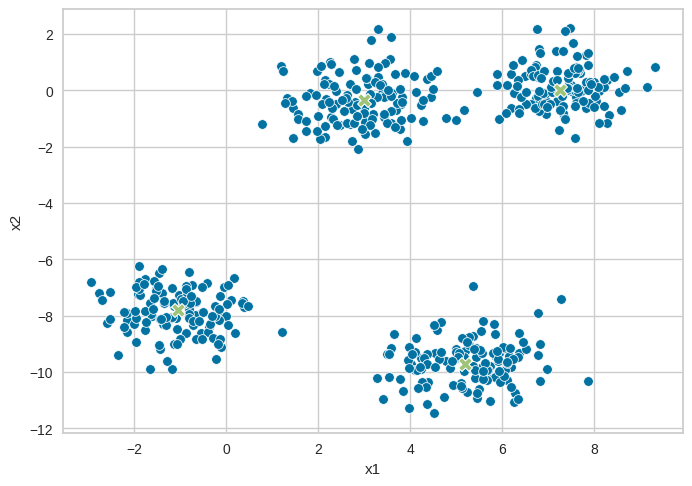

In [7]:
sns.scatterplot(data=df_blobs,x='x1',y='x2')
sns.scatterplot(data=df_centers,x='x1',y='x2',marker='X',s=100)
plt.show()

# APLICAMOS K-MEANS

In [9]:
kmeans = KMeans(n_clusters=4)
df_cluster = kmeans.fit_predict(X)
df_blobs['cluster'] = df_cluster
df_blobs

,x1,x2,y,cluster
0,3.582940,1.881899,3,2
1,7.490438,0.197777,0,0
2,6.179363,-0.612466,0,0
3,4.583479,-8.520271,1,1
4,-1.924518,-7.234382,2,3
...,...,...,...,...
495,4.204112,-9.823762,1,1
496,2.843004,-0.924989,3,2
497,4.541558,-9.836467,1,1
498,7.576625,-0.543173,0,0


In [10]:
k_means_centers = kmeans.cluster_centers_
df_k_means_center = pd.DataFrame(
    {
        'x1':k_means_centers[:,0],
        'x2':k_means_centers[:,1]
    }
)
df_k_means_center

,x1,x2
0,7.290053,0.107492
1,5.233381,-9.657108
2,2.952229,-0.342366
3,-1.069894,-7.846606


# GRAFICAMOS LOS RESULTADOS DE K-MEANS

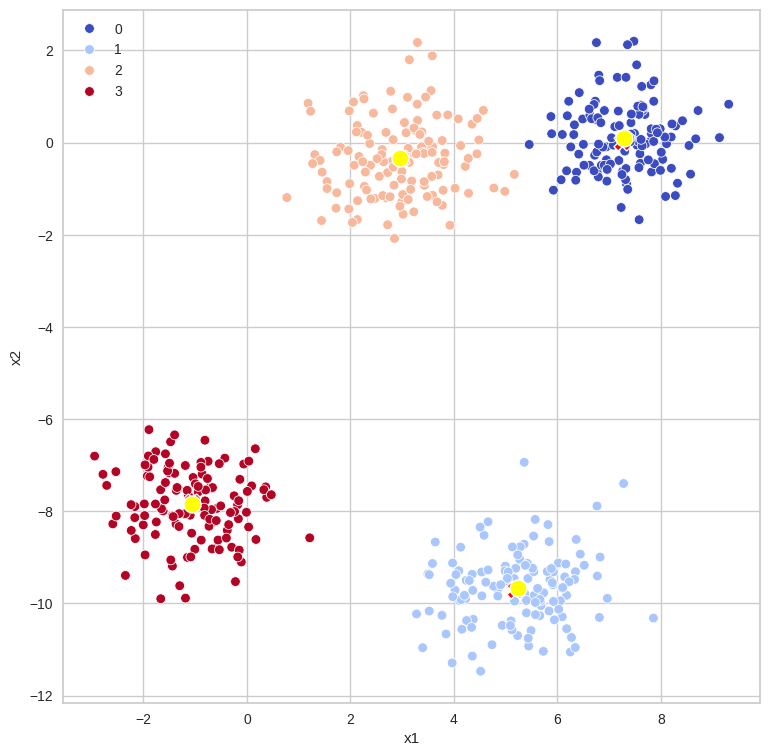

In [11]:
fig = plt.figure(figsize=(9,9))
sns.scatterplot(data=df_blobs,x='x1',y='x2',hue='cluster',palette='coolwarm')
sns.scatterplot(data=df_centers,  x='x1', y='x2', marker='X', s=150 , color='red')
sns.scatterplot(data=df_k_means_center,  x='x1', y='x2', marker='o', s=150 , color='yellow')
plt.show()